In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Data loading

In [2]:
df = pd.read_csv('data/data.csv', encoding='1251')

In [3]:
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format) # changing display format for the alternate view of DR_BCDisc	
df.head()

,DR_Dat,DR_Tim,DR_NChk,DR_NDoc,DR_Apt,DR_Kkm,DR_TDoc,DR_TPay,DR_CDrugs,DR_NDrugs,DR_Suppl,DR_Prod,DR_Kol,DR_CZak,DR_CRoz,DR_SDisc,DR_CDisc,DR_BCDisc,DR_TabEmpl,DR_VZak,DR_Pos
0,2022-08-11,10:15:35,2173,2004598,2,22577,Розничная реализация,18,45399,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,Катрен г.Химки,Д-р Редди с Лабораторис Лтд / Dr.REDDY's,1.00,41.08,51.00,12.00,925.00,200000000492.00,205,1,1.00
1,2022-08-11,10:27:46,2174,2004598,2,22577,Розничная реализация,15,261519,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,Катрен г.Химки,ФЛОРА КАВКАЗА ОАО,1.00,18.61,31.00,3.00,9.00,200010010204.00,205,1,1.00
2,2022-08-11,10:27:46,2174,2004598,2,22577,Розничная реализация,15,460864,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,Катрен г.Химки,КОРОЛЕВФАРМ ООО,1.00,132.69,209.00,20.00,9.00,200010010204.00,205,1,2.00
3,2022-08-11,10:27:46,2174,2004598,2,22577,Розничная реализация,15,172823,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,Катрен г.Химки,КОРОЛЕВФАРМ ООО,1.00,133.65,210.00,21.00,9.00,200010010204.00,205,1,3.00
4,2022-08-11,10:33:56,2175,2004598,2,22577,Розничная реализация,18,79056,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,Катрен г.Химки,Новартис Фарма АГ,1.00,709.95,787.00,49.00,925.00,200000000492.00,205,1,1.00


In [4]:
df.shape

(4462, 21)

In [5]:
df.columns

Index(['DR_Dat', 'DR_Tim', 'DR_NChk', 'DR_NDoc', 'DR_Apt', 'DR_Kkm', 'DR_TDoc',
       'DR_TPay', 'DR_CDrugs', 'DR_NDrugs', 'DR_Suppl', 'DR_Prod', 'DR_Kol',
       'DR_CZak', 'DR_CRoz', 'DR_SDisc', 'DR_CDisc', 'DR_BCDisc', 'DR_TabEmpl',
       'DR_VZak', 'DR_Pos'],
      dtype='str')

Note:
- DR_Dat - date of purchase
- DR_Tim - time of purchase
- DR_NChk - receipt number
- DR_Apt - pharmacy number
- DR_Kkm - the number of the cash shift
- DR_TDoc - documnet type
- DR_TPay - payment type
- DR_CDrugs - article of the medicinal product
- DR_NDrugs - name of the medical product
- DR_Suppl - provider
- DR_Prod - manufacturer
- DR_Kol - quantity of the product
- DR_CZak - purchase price
- DR_CRoz - retail price
- DR_SDisc - discount
- DR_CDisc - discount ID
- DR_BCDisc - discount bar code
- DR_TabEmpl - employee table number
- DR_VZak - type of purchase
- DR_Pos - item number in the receipt

In [6]:
df.dtypes

DR_Dat            str
DR_Tim            str
DR_NChk         int64
DR_NDoc         int64
DR_Apt          int64
DR_Kkm          int64
DR_TDoc           str
DR_TPay         int64
DR_CDrugs       int64
DR_NDrugs         str
DR_Suppl          str
DR_Prod           str
DR_Kol        float64
DR_CZak       float64
DR_CRoz       float64
DR_SDisc      float64
DR_CDisc      float64
DR_BCDisc     float64
DR_TabEmpl      int64
DR_VZak         int64
DR_Pos        float64
dtype: object

## 2. Data processing

In [7]:
# selecting the necessary data columns 

our_cols = ['DR_Dat', 'DR_Tim', 'DR_NChk', 'DR_NDoc', 'DR_Apt', 'DR_NDrugs', 'DR_Kol',
       'DR_CZak', 'DR_CRoz', 'DR_SDisc', 'DR_TPay', 'DR_CDrugs', 'DR_Suppl',  'DR_CDisc', 'DR_BCDisc', 'DR_TabEmpl', 'DR_VZak', 'DR_Pos']
df = df[our_cols]

# renaming columns

df.columns = ['dt', 'c_time', 'nchk', 'ndoc', 'apt', 'drug', 'kol',
       'zak', 'roz', 'disc', 'pay_type', 'drug_id', 'suppl',  'disc_id', 'disc_barcode', 'empl', 'vzak', 'pos']

In [8]:
df.head()

,dt,c_time,nchk,ndoc,apt,drug,kol,zak,roz,disc,pay_type,drug_id,suppl,disc_id,disc_barcode,empl,vzak,pos
0,2022-08-11,10:15:35,2173,2004598,2,ЦИПРОЛЕТ 3МГ/МЛ. 5МЛ. №1 ГЛ.КАПЛИ ФЛ./КАП. /Д-...,1.00,41.08,51.00,12.00,18,45399,Катрен г.Химки,925.00,200000000492.00,205,1,1.00
1,2022-08-11,10:27:46,2174,2004598,2,ПЕРЕКИСЬ ВОДОРОДА 3% 100МЛ. №40 Р-Р ФЛ.,1.00,18.61,31.00,3.00,15,261519,Катрен г.Химки,9.00,200010010204.00,205,1,1.00
2,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГЕЛЬ Д/НОГ ВЕНОТОНИЗ. ТРОКСЕРУТИН ФОРТЕ ...,1.00,132.69,209.00,20.00,15,460864,Катрен г.Химки,9.00,200010010204.00,205,1,2.00
3,2022-08-11,10:27:46,2174,2004598,2,СОФЬЯ ГХК КРЕМ Д/ТЕЛА ХОНДРОИТИН+ГЛЮКОЗАМИН 12...,1.00,133.65,210.00,21.00,15,172823,Катрен г.Химки,9.00,200010010204.00,205,1,3.00
4,2022-08-11,10:33:56,2175,2004598,2,ГАЛВУС 50МГ. №28 ТАБ. /НОВАРТИС/,1.00,709.95,787.00,49.00,18,79056,Катрен г.Химки,925.00,200000000492.00,205,1,1.00


In [9]:
# change data type (disc_barcode & disc_id columns)

df['disc_barcode'] = df['disc_barcode'].astype('str').replace(r'\.0', '', regex=True)
df['disc_id'] = df['disc_id'].astype('str').replace(r'\.0', '', regex=True)

df[['disc_barcode', 'disc_id']].head(3)

,disc_barcode,disc_id
0,200000000492,925
1,200010010204,9
2,200010010204,9


In [10]:
# change data type (vzak column)

df['vzak'] = df['vzak'].astype('str').replace('1', 'Обычный').replace('2', 'Интернет')
df['vzak'].unique()

<StringArray>
['Обычный', 'Интернет']
Length: 2, dtype: str

In [20]:
# formatting dates and times

df['dt'] = pd.to_datetime(df['dt'])
df['c_time'] = pd.to_datetime(df['c_time'], format='%H:%M:%S').dt.time

df[['dt', 'c_time']].head(3)

,dt,c_time
0,2022-08-11,10:15:35
1,2022-08-11,10:27:46
2,2022-08-11,10:27:46


In [12]:
# filling nan-values in disc_id and disc_barcode columns, so there is no more nan-values in data

df = df.fillna(0)
df.isna().any()

dt              False
c_time          False
nchk            False
ndoc            False
apt             False
drug            False
kol             False
zak             False
roz             False
disc            False
pay_type        False
drug_id         False
suppl           False
disc_id         False
disc_barcode    False
empl            False
vzak            False
pos             False
dtype: bool

## 3. EDA

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   dt            4462 non-null   datetime64[us]
 1   c_time        4462 non-null   str           
 2   nchk          4462 non-null   int64         
 3   ndoc          4462 non-null   int64         
 4   apt           4462 non-null   int64         
 5   drug          4462 non-null   str           
 6   kol           4462 non-null   float64       
 7   zak           4462 non-null   float64       
 8   roz           4462 non-null   float64       
 9   disc          4462 non-null   float64       
 10  pay_type      4462 non-null   int64         
 11  drug_id       4462 non-null   int64         
 12  suppl         4462 non-null   str           
 13  disc_id       4462 non-null   object        
 14  disc_barcode  4462 non-null   object        
 15  empl          4462 non-null   int64         
 16 

In [14]:
df.describe()

,dt,nchk,ndoc,apt,kol,zak,roz,disc,pay_type,drug_id,empl,pos
count,4462,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00,4462.00
mean,2022-08-11 10:05:45.316001,4903.14,10842995.33,10.84,1.03,241.64,306.05,10.56,16.90,259227.09,91.74,2.68
min,2022-08-11 00:00:00,1698.00,2004595.00,2.00,0.01,0.01,0.01,0.00,15.00,3.00,25.00,1.00
25%,2022-08-11 00:00:00,4187.00,6003620.00,6.00,1.00,36.64,52.00,0.00,15.00,29060.00,37.00,1.00
50%,2022-08-11 00:00:00,4877.50,11007039.00,11.00,1.00,103.78,137.00,0.00,18.00,187304.00,53.00,2.00
75%,2022-08-12 00:00:00,5472.75,18002536.00,18.00,1.00,299.06,391.75,7.00,18.00,377589.00,123.00,3.00
max,2022-08-12 00:00:00,8490.00,18002543.00,18.00,20.00,11851.13,12345.00,650.00,18.00,1504498.00,605.00,24.00
std,NaN,1839.70,6107181.40,6.11,0.54,454.56,532.17,31.37,1.45,299073.90,108.08,2.75


In [15]:
df['pay_type'].value_counts()

pay_type
18    2820
15    1642
Name: count, dtype: int64

In [16]:
df['apt'].value_counts(normalize=True)

apt
18   0.27
2    0.22
11   0.19
6    0.11
13   0.07
17   0.05
15   0.04
7    0.03
Name: proportion, dtype: float64

In [17]:
df['pos'].value_counts()

pos
1.00     2019
2.00      971
3.00      528
4.00      301
5.00      178
6.00      117
7.00       76
8.00       56
9.00       42
10.00      37
11.00      30
12.00      25
13.00      21
14.00      17
15.00      14
16.00       9
17.00       7
18.00       4
19.00       3
20.00       2
21.00       2
23.00       1
24.00       1
22.00       1
Name: count, dtype: int64

<Axes: >

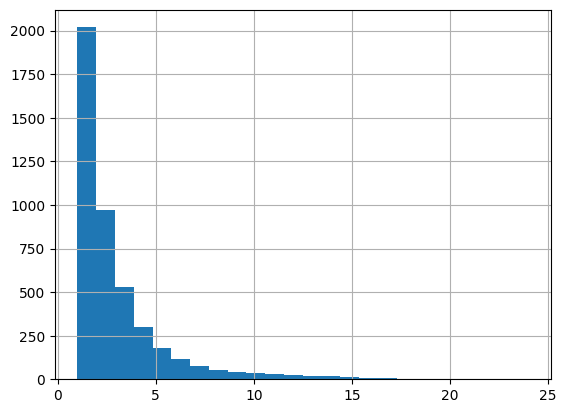

In [18]:
df['pos'].hist(bins=24)

<Axes: >

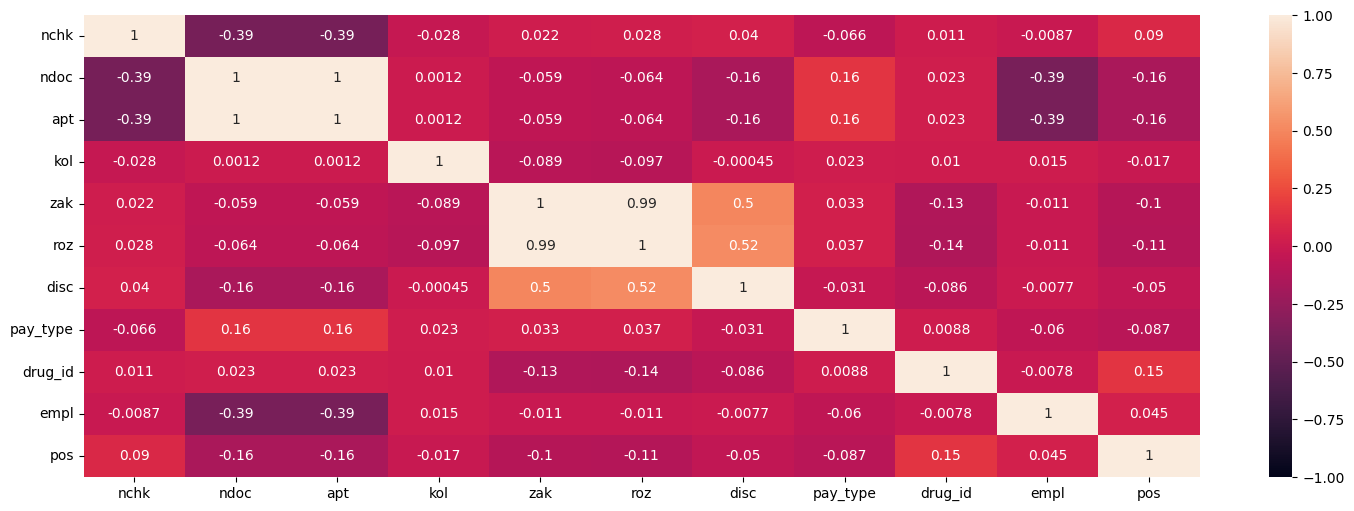

In [28]:
# correlation matrix of data

numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(18,6))
sns.heatmap(numeric_df.corr(), vmax=1, vmin=-1, annot=True)